# **Deep Reinforcement Learning Class Spring 2026 Assignment 1**

In this assignment, we will learn about gym interface, gridworld, q-learning, and etc. You will need to answer the bolded questions and fill in the missing code snippets (marked by TODO).

Make a copy of this notebook using File > Save a copy in Drive and edit it with your answers.

# **Question 1:** Implement and Familiarize Yourself with a Grid World Environment
We will first become familiar with the grid world environment.

In this question, you need to implement a simple 5×5 grid world from scratch. Specifically, you should define functions such as reset(), step(), and render().

Additionally, you should explore and gain familiarity with MiniGrid in OpenAI Gym.

To define our GridWorldEnv.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import time

class GridWorldEnv:
    def __init__(self, size=5):
        self.size = size
        self.agent_pos = [0, 0]  # Start position
        self.goal_pos = [size - 1, size - 1]  # Goal position
        self.done = False

    def reset(self):

        # TODO: Reset the agent's position to (0,0)
        self.agent_pos = [0, 0]


        # TODO: Set `done` to False
        self.done = False


        # TODO: Return the initial state as a NumPy array
        return np.array(self.agent_pos)


    def step(self, action):

        # TODO: Implement movement logic based on the given action

        new_pos = self.agent_pos.copy()

        if action == 0:  # Up (↑)
            new_pos[0] -= 1

        elif action == 1:  # Right (→)
            new_pos[1] += 1

        elif action == 2:  # Down (↓)
            new_pos[0] += 1

        elif action == 3:  # Left (←)
            new_pos[1] -= 1

        reward = 0.0

        if 0 <= new_pos[0] < self.size and 0 <= new_pos[1] < self.size:
            self.agent_pos = new_pos
            reward -= 0.2

        # TODO: Implement reward logic
        # After moving, calculate the reward (+5 for goal, -0.2 per step) and set `done=True`
        if self.agent_pos == self.goal_pos:
            self.done = True
            reward += 5.0

        # TODO: Return the new state (NumPy array), reward, and `done` status
        return np.array(self.agent_pos), reward, self.done

    def render(self):

        '''
        Render the environment
        Draw the grid, marking the agent and the goal
        '''

        # TODO: Create a grid of zeros with shape (size, size)
        grids = np.zeros((self.size, self.size))


        # TODO: Mark the goal position with 2
        grids[self.goal_pos[0], self.goal_pos[1]] = 2


        # TODO: Mark the agent position with 1
        grids[self.agent_pos[0], self.agent_pos[1]] = 1


        # TODO: Display the grid using matplotlib
        plt.imshow(grids)
        plt.show()


This cell of code is designed to verify whether your implementation of the MiniGrid environment is correct.

⚠️ **Do not modify this cell**—any changes will result in a score of **0** for your own GridWorldEnv code above.

🎯 How to Get 7 Points?  
 1️⃣ Run the code below successfully.  
 2️⃣ Observe the agent randomly moving in the 3x3 GridWorld.(2 pts for reset/ 2 pts for render)  
 3️⃣ The agent should reach the goal (🏆) eventually and stop.(3pts for step)  
 4️⃣ If everything works, congratulations! You earned 7 points! 🎉  

In [ ]:
import random

env = GridWorldEnv(size=3)
obs = env.reset()
done = False

print("🚀 Random Action Agent Starts!")
while not done:
    action = random.choice([0, 1, 2, 3])
    obs, reward, done = env.step(action)
    env.render()
    print(f"Action: {action}, Reward: {reward}, Done: {done}")
    time.sleep(0.5)


## **Setup**
Run the following skeleton code to set up the necessary imports and plotting functions.

In [ ]:
!pip -q install -U gymnasium minigrid matplotlib imageio
import gymnasium as gym
import minigrid
import imageio
from IPython.display import Image, display
import math

## **Understanding the Gym MiniGrid Environment**
In this section, we will initialize a MiniGrid environment and explore its key properties.

***What is MiniGrid?***

MiniGrid is a lightweight grid world environment designed for reinforcement learning. The agent interacts with the environment by taking actions, receiving observations, and collecting rewards. It serves as an ideal testing ground for developing and evaluating reinforcement learning algorithms.

Simply execute this cell to retrieve key information about the environment.

In [ ]:
# setup Environment
env = gym.make("MiniGrid-Empty-8x8-v0", render_mode="rgb_array")

obs, info = env.reset()

# environment information
print("Action Space:", env.action_space)
print("Observation Keys:", obs.keys())
print("Observation Shape:", obs['image'].shape)


## **Implementing a Random Agent in MiniGrid**
In this section, you will implement a random agent in the MiniGrid environment. This exercise will help you understand how the agent interacts with the environment by taking actions, receiving rewards, and updating the environment state.

🎯 How to Get 3 Points?  
 1️⃣ Successfully execute the following code.  
 2️⃣ The random agent should move freely in the environment.  
 3️⃣ The animation of the agent’s movement should be generated.  
 4️⃣ The total accumulated reward should be displayed.  
 5️⃣ If everything works correctly, congratulations! You earned 3 points! 🎉  


In [ ]:
# Setup environment (render_mode is required to get RGB frames via env.render()).
env = gym.make("MiniGrid-Empty-8x8-v0", render_mode="rgb_array")
obs, info = env.reset()

frames = []          # Stores rendered frames for GIF export
total_reward = 0.0   # Accumulates episode reward
max_steps = 200      # Safety cap to avoid infinite loops

for t in range(max_steps):
    # TODO: Select an action randomly
    action = env.action_space.sample()

    # TODO: Take a step in the environment
    obs, reward, terminated, truncated, info = env.step(action)

    # TODO: Update the total reward
    total_reward += reward

    # Render current frame as an RGB array.
    frame = env.render()

    frames.append(frame.copy())

    if terminated or truncated:
        break

print("Total Reward:", total_reward)

gif_path = "./content/minigrid.gif"
imageio.mimsave(gif_path, frames, fps=5)
Image(filename=gif_path)


Simply execute this cell to explore the available actions that an agent can take in the MiniGrid environment. Understanding these actions will help you better navigate and interact with the environment.

In [ ]:
actions_enum = env.unwrapped.actions  # Actions Enum class (MiniGrid)
actions = {i: actions_enum(i).name for i in range(env.action_space.n)}
print("Available Actions:", actions)


## **Implementing a Rule-Based Agent in MiniGrid**
In this section, you will implement a **simple rule-based agent** to navigate the **MiniGrid environment**. This will help you gain a deeper understanding of **observations**, **actions**, and **rewards** before progressing to **reinforcement learning**.

🎯 How to Get 5 Points?  
 1️⃣ Successfully execute the following code.  
 2️⃣ The rule-based agent should move based on rule in the environment.  
 3️⃣ The animation of the agent’s movement should be generated.  
 4️⃣ The total accumulated reward should be displayed.  
 5️⃣ If everything works correctly, congratulations! You earned 5 points! 🎉  

In [ ]:
def rule_based_agent(obs):
    '''
      Simple Rule-Based Agent:
        Turns if a wall is ahead
        Otherwise, Moves forward
    '''
    goal_id, wall_id, agent_id = 8, 2, 1  # TODO: Define the object IDs for the goal, walls, and agent
    direction = obs['direction']  # TODO: Retrieve the agent's current facing direction

    # TODO: Find the agent's position within the observation grid (obs['image'])

    # TODO: Extract the agent's coordinates

    # TODO: Calculate the coordinates of the cell directly in front of the agent based on its direction

    # TODO: Ensure `front_x, front_y` remains within valid grid boundaries

    # TODO: Implement decision-making logic (Turns if a wall is ahead && Otherwise, Moves forward)

    # In the local obs['image'], the agent view is usually 7x7
    # The agent itself is at (3, 6) facing 'up' in the local view
    
    image = obs['image']
    
    # The cell directly in front of the agent in its LOCAL view is at:
    # Width: Middle (index 3), Height: One row up from bottom (index 5)
    front_cell = image[3, 5] 
    
    obj_type = front_cell[0] # The first channel is the object ID
    
    # Decision Logic:
    if obj_type == 2:  # If it's a Wall
        return 1       # Action 1: Turn Right
    return 2       # Action 2: Move Forward


done = False
total_reward = 0
frames = []

obs, info = env.reset()

while not done:
    action = rule_based_agent(obs)  # Execute the rule-based policy

    obs, reward, terminated, truncated, info = env.step(action)
    # TODO: Update termination condition using terminated/truncated
    if terminated or truncated:
        done = True

    total_reward += float(reward)

    frame = env.render()
    frames.append(frame.copy())

# Do not modify the follwing code—any changes will result in a score of **0** for this cell.
print("Total Reward:", total_reward)

gif_path = "./content/minigrid.gif"
imageio.mimsave(gif_path, frames, fps=5)


Image(filename=gif_path)


# **Question 2: Reinforcement Learning with Tabular Methods**

In this section, we will explore **reinforcement learning (RL)** by implementing tabular-based **value learning** and **policy learning** in MiniGrid environments.

You will investigate two fundamental approaches in reinforcement learning:

## **📌 Value-Based Learning (Q-Learning)**
- Uses a **Q-table** to store action-value estimates for each state.
- The agent **updates Q-values** based on rewards received from the environment.
- Helps the agent **learn an optimal policy** by maximizing future rewards.

## **📌 Policy-Based Learning**
- Instead of learning a Q-table, it **learns a direct policy** (i.e., a mapping from states to actions).
- Can be implemented using **tabular-based policy iteration**.
- Helps understand how an agent can **directly optimize its behavior** without relying on Q-values.


## **Value-Based Learning (Q-Learning)**  

- Uses **Q-tables** to store action values for each state.  
- Applies the **Bellman equation** to update Q-values.  
- Implements **ε-greedy exploration** to balance exploration and exploitation.  


🎯 **How to Get 10 Points?**  
1️⃣ Correctly implement the **Q-learning training procedure**.  
2️⃣ The agent must be trained using **Q-tables** and the training loop should update Q-values properly.  

3️⃣ After training, successfully **demonstrate the learned policy** in the environment.  
4️⃣ Generate an **animation (GIF/video)** showing the trained agent running in the environment.  

5️⃣ You get **10 points only if both** the training process is correctly implemented **and** the animation is successfully displayed/generated. 🎉  


In [ ]:
def tabular_q_learning(env_name="MiniGrid-Empty-8x8-v0", episodes=5000, alpha=0.1, gamma=0.99,
                       epsilon_start=1.0, epsilon_end=0.1, decay_rate=0.999):
    '''
      Implementing Tabular Q-Learning with Epsilon Decay
      - Uses a **Q-table** to store action values for each state.
      - Updates Q-values using the **Bellman equation**.
      - Implements **ε-greedy exploration** for action selection.
    '''

    action_space_n = 3  # check out the minigrid document to know the number

    env = gym.make(env_name)
    q_table = {}  # Initialize an empty Q-table to store state-action values.

    rewards_per_episode = []
    epsilon = epsilon_start  # Initialize epsilon for the exploration-exploitation tradeoff.

    def get_state(env):
        # TODO: Represent the state using the agent's position and direction.
        # return env.agent_pos, env.agent_dir
        return env.unwrapped.agent_pos, env.unwrapped.agent_dir


    for episode in range(episodes):
        # TODO: Reset the environment at the beginning of each episode.
        env.reset()
        state = get_state(env)
        done = False
        total_reward = 0.0

        while not done:
            # TODO: Initialize the state in the Q-table if it is not already present.
            if state not in q_table:
                q_table[state] = np.zeros(action_space_n)

            # TODO: Implement an ε-greedy policy for action selection.
            if np.random.random() < epsilon:
                action = np.random.randint(0,action_space_n)  # Explore
            else:
                # action = np.argmax(q_table[state])  # Exploit
                action = np.random.choice(np.where(q_table[state] == np.max(q_table[state]))[0])

            # TODO: Execute the action and observe the next state and reward.
            next_obs, reward, terminated, truncated, info = env.step(action)

            # TODO: Update termination condition using terminated/truncated.
            if terminated:
                done = True

            next_state = get_state(env)
            total_reward += float(reward)
            # if reward != 0:
            #     print(f'is not 0: {reward}')

            # TODO: Initialize next_state in the Q-table if it is not already present.
            if next_state not in q_table:
                q_table[next_state] = np.zeros(action_space_n)

            # TODO: Apply the Q-learning update rule (Bellman equation).
            # Formula: Q(s,a) = Q(s,a) + alpha * [reward + gamma * max(Q(s',a')) - Q(s,a)]
            best_next_action = np.max(q_table[next_state])
            td_target = reward + gamma * best_next_action
            td_error = td_target - q_table[state][action]
            q_table[state][action] += alpha * td_error


            # TODO: Update the state to the next state.
            state = next_state


        rewards_per_episode.append(total_reward)

        # TODO: Decay epsilon over time to gradually reduce exploration.
        epsilon = max(epsilon_end, epsilon * decay_rate)


        if (episode + 1) % 100 == 0:
            avg_reward = np.mean(rewards_per_episode[-100:])
            print(f"Episode {episode + 1}/{episodes}, Avg Reward: {avg_reward:.4f}, Epsilon: {epsilon:.3f}")

    env.close()
    return q_table, rewards_per_episode


Train the agent in **MiniGrid-Empty-8x8**.  

⚠️ Any changes will result in a score of **0** for your training code above.


In [ ]:
q_table, rewards = tabular_q_learning("MiniGrid-Empty-8x8-v0", episodes=2000)

plt.plot(rewards)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Q-learning Training Progress")
plt.show()

After training the agent using **Q-learning**, we will now evaluate its performance in the environment.  

This function runs a **single test episode** using the learned **Q-table** and records the agent's movement as a **GIF**.


In [ ]:
def run_learned_value(env_name, q_table, max_steps=100, gif_path="./content/minigrid_q_learning.gif"):

    action_space_n = 3

    env = gym.make(env_name, render_mode="rgb_array")
    obs, info = env.reset()

    # TODO: Retrieve the initial state
    state = env.unwrapped.agent_pos, env.unwrapped.agent_dir
    done = False


    frames = []
    total_reward = 0  # Tracks the total accumulated reward.

    frame = env.render()
    frames.append(frame.copy())

    for _ in range(max_steps):
        # TODO: Select an action based on the learned Q-table.
        action = np.argmax(q_table[state])  # Exploit

        # TODO: Execute the chosen action and observe the outcome.
        next_obs, reward, terminated, truncated, info = env.step(action)

        # TODO: Update termination condition using terminated/truncated
        total_reward += float(reward)  # Update the total reward.
        if terminated or truncated:
            done = True

        # TODO: Update the agent's state.
        state = env.unwrapped.agent_pos, env.unwrapped.agent_dir

        frame = env.render()
        frames.append(frame.copy())

        if done:
            break

    env.close()

# Do not modify the follwing code—any changes will result in a score of **0** for this cell and also your training code above.
    imageio.mimsave(gif_path, frames, fps=5)
    print(f"Total Reward: {total_reward}")

    return Image(filename=gif_path)

# ✅ Run the trained agent using the learned value-based policy.
run_learned_value("MiniGrid-Empty-8x8-v0", q_table)


## **Policy-Based Learning**  
- Uses a **policy table** to store action probabilities for each state instead of Q-values.  
- Applies **policy gradient methods** to directly optimize the policy, rather than using the Bellman equation.  
- Uses **softmax action selection**, meaning actions are chosen probabilistically instead of always picking the one with the highest value.  

### **🔑 Key Differences from Value-Based Learning (Q-Learning)**  
| Feature            | Value-Based Learning (Q-Learning) | Policy-Based Learning (Policy Gradient) |
|--------------------|---------------------------------|----------------------------------------|
| **Learning Target** | Learns **Q-values** (action values) | Learns **action probabilities** (policy function) |
| **Action Selection** | Uses **ε-greedy** to choose the best Q-value | Uses **softmax** or a stochastic policy to sample actions |
| **Update Method** | Updates Q-values using the **Bellman equation** | Updates the policy directly using **policy gradients** |
| **Exploration Strategy** | Requires **ε-decay** to balance exploration | Exploration is **inherent** in the policy |
| **Best For** | **Discrete action spaces** (small state spaces) | **Continuous or large action spaces** |

## **📌 Summary**  
- **Q-Learning** learns **what the best action is** by estimating values for each action.  
- **Policy Learning** learns **how to act directly**, optimizing the probability of taking actions.  
- **Policy Learning is better for complex, continuous environments**, while **Value Learning is more efficient in simple, discrete environments**. 🚀

🎯 **How to Get 5 Points?**  
1️⃣ Correctly implement the **policy learning training procedure** (e.g., REINFORCE-style updates).  
2️⃣ The agent must be trained using a **policy-table** and the training loop should update the policy properly.  

3️⃣ After training, successfully **demonstrate the learned policy** in the environment. *(4 points)*  
4️⃣ Generate an **animation (GIF/video)** showing the trained agent running in the environment. *(1 point)*  

5️⃣ You get **5 points only if both** the training procedure is correctly implemented **and** the animation is successfully displayed/generated. 🎉

In [ ]:
def tabular_policy_learning(env_name="MiniGrid-Empty-8x8-v0", episodes=5000, alpha=0.1, gamma=0.99):
    
    action_space_n = 3

    env = gym.make(env_name)
    # Initialize an empty policy table to store action probabilities.
    policy_table = dict()   # policy_table is the theta in pi(a|s, theta)

    rewards_per_episode = []

    def get_state(env):
        # TODO: Represent the state using the agent's position and direction.
        return env.unwrapped.agent_pos, env.unwrapped.agent_dir


    def softmax(x):
        # TODO: Compute softmax values for an array.
        # e_x = np.exp(x - np.max(x))   # to prevent overflow
        e_x = np.exp(x)
        return e_x / e_x.sum()


    for episode in range(episodes):
        obs, info = env.reset()
        state = get_state(env)
        done = False
        total_reward = 0.0
        trajectory = []  # Store (state, action, reward) for policy update

        while not done:
            # TODO: Initialize the policy logits for this state if it is not already present.
            #       The table stores unnormalized preferences (logits), not probabilities.
            if state not in policy_table:
                policy_table[state] = np.zeros(action_space_n)

            # TODO: Compute the softmax action distribution pi(a|s) from the state's logits.
            pi = softmax(policy_table[state])

            # TODO: Sample an action from pi(a|s).
            action = np.random.choice(action_space_n, p=pi)

            # TODO: Execute the action and observe reward and termination flags.
            next_obs, reward, terminated, truncated, info = env.step(action)

            # TODO: Mark episode as done if terminated or truncated.
            done = terminated or truncated

            # TODO: Extract the next state representation (must match the training state definition).
            next_state = get_state(env)

            # TODO: Accumulate episode reward for logging.
            total_reward += reward

            # TODO: Store (state, action, reward) for return computation and policy update.
            trajectory.append((state, action, reward))

            # TODO: Move to the next state.
            state = next_state


        rewards_per_episode.append(total_reward)

        # Policy Update (REINFORCE-like on a tabular softmax policy)
        G = 0.0  # discounted return
        for t in reversed(range(len(trajectory))):
            state, action, reward = trajectory[t]

            # TODO: Compute discounted return.
            G = reward + gamma * G

            # TODO: Compute the policy gradient update for softmax logits
            # Check out more detail about softmax function 
            # and the gradient of softmax function (so beautiful)
            pi = softmax(policy_table[state])
            grad_log_pi = -pi
            grad_log_pi[action] += 1.0
            policy_table[state] += alpha * (gamma**t) * G * grad_log_pi

        if (episode + 1) % 100 == 0:
            avg_reward = np.mean(rewards_per_episode[-100:])
            print(f"Episode {episode + 1}/{episodes}, Avg Reward: {avg_reward:.4f}")

    env.close()
    return policy_table, rewards_per_episode


Train the agent in **MiniGrid-Empty-8x8** using **policy learning**.  

⚠️ Any changes will result in a score of **0** for your training code above.

In [ ]:
# Train the agent using policy-based learning.
policy_table, rewards = tabular_policy_learning("MiniGrid-Empty-8x8-v0", episodes=2000)

# Plot the training progress.
plt.plot(rewards)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Tabular Policy Learning Training Progress")
plt.show()

Now that you have trained your agent using **tabular policy learning**, let's visualize its performance in the **MiniGrid environment**.  

This function runs a **test episode** using the learned **policy table (π-table)** and records the agent's movement as a **GIF**.


In [ ]:
def run_learned_policy(env_name, policy_table, max_steps=100, gif_path="./content/minigrid_policy_learning.gif"):
    '''
      Runs a learned policy in a MiniGrid environment and saves an animation GIF.
      :param env_name: (str) Gym environment name
      :param policy_table: (dict) Trained policy table (π)
      :param max_steps: (int) Maximum steps for the episode
      :param gif_path: (str) Path to save the GIF
    '''

    def softmax(x):
        # TODO: Compute softmax values for an array.
        # e_x = np.exp(x - np.max(x))   # to prevent overflow
        e_x = np.exp(x)
        return e_x / e_x.sum()
    
    action_space_n = 3
    
    env = gym.make(env_name, render_mode="rgb_array")
    obs, info = env.reset()

    # TODO: Retrieve the initial state
    state = env.unwrapped.agent_pos, env.unwrapped.agent_dir
    done = False


    frames = []
    total_reward = 0  # Track total accumulated reward


    frame = env.render()
    frames.append(frame.copy())

    for _ in range(max_steps):
        # TODO: Choose an action using the learned policy table
        # action = (
        #     np.argmax(policy_table[state]) 
        #     if state in policy_table 
        #     else np.random.randint(action_space_n)
        # )
        if state not in policy_table:
            policy_table[state] = np.zeros(action_space_n)
        pi = softmax(policy_table[state])
        action = np.random.choice(action_space_n, p=pi)

        obs, reward, terminated, truncated, info = env.step(action)
        # TODO: Update termination condition using terminated/truncated
        total_reward += float(reward)  # Update total reward
        done = terminated or truncated

        # TODO: Update the agent's state
        state = env.unwrapped.agent_pos, env.unwrapped.agent_dir


        frame = env.render()
        frames.append(frame.copy())

        if done:
            break

    env.close()

# Do not modify the follwing code—any changes will result in a score of **0** for this cell and also your training code above.
    imageio.mimsave(gif_path, frames, fps=5)
    print(f"Total Reward: {total_reward}")

    return Image(filename=gif_path)

# Run the trained policy
run_learned_policy("MiniGrid-Empty-8x8-v0", policy_table)


In this section, you will train an agent using **Q-learning** in the **MiniGrid-BlockedUnlockPickup-v0** environment.  

However, you will likely find that the agent **fails to learn efficiently** in this more complex environment.  

You can comment out the training code to avoid retraining the agent every time you run this notebook.


In [ ]:
# q_table, rewards = tabular_q_learning("MiniGrid-BlockedUnlockPickup-v0", episodes=2000, epsilon_start=1.0, epsilon_end=0.1, decay_rate=0.9995)

Now that we have trained an agent using **Q-learning** on **MiniGrid-BlockedUnlockPickup-v0**, let's evaluate its performance.

You can also comment out this cell.

In [ ]:
# Run the trained value once
# run_learned_value("MiniGrid-BlockedUnlockPickup-v0", q_table)


## **Reward Shaping**  

If the agent only receives a reward upon reaching the goal, how can it learn that **picking up the key** and **opening the door** are necessary steps?  

This is where **Reward Shaping** comes into play.  

### **📌 What is Reward Shaping?**  
Reward shaping is a technique used in **reinforcement learning (RL)** to provide additional rewards that help guide the agent toward desirable behaviors. Instead of giving a reward only when the agent completes the task, intermediate rewards are introduced to **reinforce progress** toward the goal.  

### **🛠 Why Use Reward Shaping?**  
- **Speeds up learning**: Helps the agent learn useful behaviors more quickly.  
- **Encourages exploration**: Provides incentives for discovering key steps in complex environments.  
- **Reduces sparse reward problems**: Addresses situations where rewards are given only at the end of an episode, making learning difficult.  

### **🎯 Example: Reward Shaping in MiniGrid-BlockedUnlockPickup**  
In **MiniGrid-BlockedUnlockPickup-v0**, the agent must:  
1. **Move the blocking ball out of the way**  
2. **Find and pick up the key**  
3. **Navigate to the locked door and unlock it**  
4. **Go inside and pick up the box to finish the episode**  

Without reward shaping, the agent may struggle to associate early sub-goals—especially **clearing the blockage** and **obtaining the key**—with the delayed terminal reward, making learning slow and unstable.

### **🚀 Key Takeaway**  
Reward shaping **bridges the gap between sparse rewards and effective learning**. It guides the agent by providing structured feedback, helping it navigate complex tasks more efficiently.

🎯 **How to Get 20 Points? (Q-table + Reward Shaping Evaluation)**

1️⃣ Successfully implement **reward shaping** to train an agent.  
2️⃣ The agent should learn to navigate the environment using **Q-tables** (not a neural network).  
3️⃣ After training, evaluate your learned Q-table by running **20 episodes** (e.g., `run_learned_value_adjust_eps(..., n_episodes=20)`).  
4️⃣ **Success definition (per episode):** if the agent obtains **any positive reward (`reward > 0`)** during that episode, it counts as **1 success**.  
5️⃣ You must generate an **animation (GIF)** showing the trained agent’s behavior during evaluation.

✅ **Scoring is based on the number of successes out of 20 episodes:**
- **15–20 successes → 20 points**
- **11–14 successes → 15 points**
- **7–10 successes → 10 points**
- **3–6 successes → 5 points**
- **0–2 successes → 0 points**


In [253]:
import numpy as np
import gymnasium as gym

def tabular_q_learning_adjust(
    env_name="MiniGrid-BlockedUnlockPickup-v0",
    episodes=6500,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.1,
    decay_rate=0.9997,
    reward_shaping=True,
    q_table=None,
    debug=False,
):

    action_space_n = 6

    env = gym.make(env_name)
    base_env = env.unwrapped

    if q_table is None:
        q_table = {}

    rewards_per_episode = []
    epsilon = epsilon_start

    env_rewards_100 = []
    shaped_rewards_100 = []
    success_100 = []


    def _iter_grid_objects():

        # Helper functions like this to read useful objects
        # from the environment grid.
        grid = base_env.grid
        for x in range(grid.width):
            for y in range(grid.height):
                obj = grid.get(x, y)
                if obj is not None:
                    yield x, y, obj

    # object types: wall, floor, ball, key, door, box
    def _find_first_obj(obj_type):

        # Helper functions to search for important objects
        # in the environment if needed for your state design or reward shaping.
        for x, y, obj in _iter_grid_objects():
            if getattr(obj, "type", None) == obj_type:
                return x, y, obj
        return None, None, None

    def _carrying_type():
        return None if base_env.carrying == None else base_env.carrying.type






    # TODO: You may define your own helper functions here to support training.
    # For example, they may help you read useful environment information,
    # design state features, or implement reward shaping. However, you are
    # free to organize these helpers in your own way, as long as your agent
    # can learn the task correctly.

    small_reward = 0.1
    large_reward = 10.0

    class EnvInfo:
        def __init__(self, base_env, ball_init_pos):
            self.base_env = base_env
            self.ball_init_pos = ball_init_pos

    class State:
        def __init__(self, carrying=None,
                     progress=0, next_obj_dir=(0,0), next_obj_type=None, obj_around=None):
            # basic attributes
            # self.dir = dir
            # self.pos = pos
            self.carrying = carrying

            self.progress = progress

            self.next_obj_dir = next_obj_dir
            
            self.next_obj_type = next_obj_type

            self.obj_around = obj_around

    # ---

    def done_state_tuple():
        return None, 8, None, None, None

    def fail_state_tuple():
        return None, -1, None, None, None

    def get_state(env_info: EnvInfo):

        # TODO: Design your own state representation.

        # Your state does not need to follow any fixed design, but it should
        # contain enough information for the agent to learn effectively. It is
        # recommended to include at least position-related information, the
        # agent's direction, and any additional information required by your
        # reward shaping. Think about what the agent needs to observe in order
        # to understand the behaviors you want it to learn. For example, if
        # picking up the key is rewarded, then the state should include enough
        # information for the agent to recognize that event.
        if _find_first_obj('box') == (None, None, None):
            if _carrying_type() == 'box':
                return done_state_tuple()
            # If the agent toggle the box, the box will disappear.
            return fail_state_tuple()
        base_env = env_info.base_env
        # determine state.carrying
        state = State(_carrying_type())
        
        # determine state.progress
        cur_ball_x, cur_ball_y, _ = _find_first_obj('ball')
        _, _, door_obj =  _find_first_obj('door')
        front_pos = base_env.front_pos
        front_obj = base_env.grid.get(front_pos[0], front_pos[1])
        front_obj_type = None if front_obj == None else front_obj.type

        if (cur_ball_x, cur_ball_y) == tuple(env_info.ball_init_pos):
            state.progress = 2 if state.carrying == 'ball' else 0
        elif door_obj.is_locked:
            if state.carrying == 'ball' and (front_pos[0], front_pos[1]) == tuple(env_info.ball_init_pos):
                state.progress = 1
            else:
                match state.carrying:
                    case 'ball': state.progress = 2
                    case None:   state.progress = 3
                    case 'key':  state.progress = 4
        elif not door_obj.is_open:
            state.progress = 5
        elif state.carrying != None:
            state.progress = 6
        else:
            state.progress = 7

        # determine next_object_side
        # agent dir: (0, right), (1, down), (2, left), (3, up)
        # side: (0, right), (1, back), (2, left), (3, front)
        # right: x increase, down: y increase
        state.next_obj_type = None
        match state.progress:
            case 0: state.next_obj_type = 'ball'
            case 1: state.next_obj_type = 'init_ball'
            case 3: state.next_obj_type = 'key'
            case 4 | 5: state.next_obj_type = 'door'
            case 6 | 7: state.next_obj_type = 'box'

        agent_x, agent_y = base_env.agent_pos

        if state.next_obj_type == None:
            state.next_obj_dir = -1
        else:
            next_x, next_y, _ = _find_first_obj(state.next_obj_type)
            if state.next_obj_type == 'init_ball':
                next_x, next_y = env_info.ball_init_pos

            delta_x = 0 if agent_x == next_x else (next_x - agent_x)//abs(next_x - agent_x)
            delta_y = 0 if agent_y == next_y else (next_y - agent_y)//abs(next_y - agent_y)

            # agent dir: (0, right), (1, down), (2, left), (3, up)
            # next_object_dir = ((front(1), back(-1) or none(0)), (right(1), left(-1) or none(0)))
            match base_env.agent_dir:
                case 0: state.next_obj_dir = (delta_x, delta_y)
                case 1: state.next_obj_dir = (delta_y, -delta_x)
                case 2: state.next_obj_dir = (-delta_x, -delta_y)
                case 3: state.next_obj_dir = (-delta_y, delta_x)

        dx = front_pos[0] - agent_x
        dy = front_pos[1] - agent_y
        right_pos = (agent_x - dy, agent_y + dx)
        back_pos = (agent_x - dx, agent_y - dy)
        left_pos = (agent_x + dy, agent_y - dx)

        right_obj = base_env.grid.get(right_pos[0], right_pos[1])
        back_obj = base_env.grid.get(back_pos[0], back_pos[1])
        left_obj = base_env.grid.get(left_pos[0], left_pos[1])
        right_obj_type = None if right_obj == None else right_obj.type
        back_obj_type = None if back_obj == None else back_obj.type
        left_obj_type = None if left_obj == None else left_obj.type

        state.obj_around = (right_obj_type, back_obj_type, left_obj_type, front_obj_type)

        return state.carrying, state.progress, state.next_obj_dir, state.next_obj_type, state.obj_around





    def _reset_env():
        return env.reset()

    def _step_env(action):
        obs, reward, terminated, truncated, info = env.step(action)
        done = bool(terminated or truncated)
        return obs, float(reward), bool(terminated), bool(truncated), info, done


    for episode in range(episodes):
        obs, info = _reset_env()

        # TODO: related to my state design and get_state() function
        init_ball_x, init_ball_y, _ = _find_first_obj('ball')
        ball_init_pos = np.array([init_ball_x, init_ball_y])
        env_info = EnvInfo(base_env, ball_init_pos)

        state_tuple = get_state(env_info)
        state = State(*state_tuple)

        total_reward = 0.0
        total_env_reward = 0.0
        total_shaped_reward = 0.0

        done = False
        step_count = 0

        # For reward shaping, such as whether a subgoal has already been rewarded.
        # got_key = False
        # got_open = False
        got_success = False
        # got_pick_ball = False

        furthest_progress = 0

        # TODO: You may define your own helper variables or flags here
        # if your reward shaping needs to track extra events or multi-step behaviors.



        # TODO: You may store any previous-step information here if your
        # reward shaping depends on state transitions across steps.
        pre_pos = base_env.agent_pos


        while not done:
            step_count += 1

            if state_tuple not in q_table:
                q_table[state_tuple] = np.zeros(env.action_space.n, dtype=np.float32)

            # TODO: Choose an action using an exploration strategy
            # such as epsilon-greedy.
            if np.random.random() < epsilon:
                action = np.random.randint(0, action_space_n)  # Explore
            else:
                # action = np.argmax(q_table[state])  # Exploit
                action = np.random.choice(np.where(q_table[state_tuple] == np.max(q_table[state_tuple]))[0])

            # TODO: You may update helper variables here if your reward shaping
            # depends on action context or multi-step behavior patterns.


            # TODO: Execute the selected action in the environment.
            obs, env_reward, terminated, truncated, info, done = _step_env(action)
            done |= state_tuple == fail_state_tuple()

            # action: (0,1,2,3,4,5,6) = (left, right, forward, pickup, drop, toggle)
            next_state_tuple = get_state(env_info)
            next_state = State(*next_state_tuple)

            shaped_reward = 0.0

            # TODO: Read any new environment status needed for reward shaping if needed


            if reward_shaping:
                # TODO: Add reward shaping.
                # You may want to encourage useful intermediate behaviors, such as:
                # 1. picking up the blocking ball
                # 2. picking up the key
                # 3. opening the door
                #
                # You are free to design your own reward shaping strategy.
                # Additional rewards or penalties may also help improve learning efficiency.
                # TODO: Encourage the agent to pick up the blocking ball.
                # TODO: Encourage the agent to pick up the key.
                # TODO: Encourage the agent to open the door.
                # TODO: You may add more reward shaping to help training, for example
                # by penalizing bad actions or rewarding useful intermediate behaviors.
                # However, be careful that your design does not let the agent exploit
                # the shaping reward repeatedly without solving the real task in the
                # environment.

                # if state == fail_state():
                #     shaped_reward -= large_reward

                # furthest_progress = max(furthest_progress, next_state.progress)

                # if next_state.progress > furthest_progress:
                #     shaped_reward += next_state.progress - furthest_progress 
                #     furthest_progress = next_state.progress

                if next_state.progress < state.progress:
                    shaped_reward -= 0.2

                if pre_pos == base_env.agent_pos:
                    shaped_reward -= 0.1

                # if state.progress >= 5 and pre_pos == base_env.agent_pos:
                #     shaped_reward -= 0.05

                shaped_reward += gamma * next_state.progress * 0.1 - state.progress * 0.1
                # shaped_reward += gamma * next_state.progress - state.progress

                # ---


            if (not got_success) and terminated:
                shaped_reward += 10.0
                got_success = True

            reward = float(env_reward) + float(shaped_reward)

            total_env_reward += float(env_reward)
            total_shaped_reward += float(shaped_reward)
            total_reward += float(reward)

            if next_state_tuple not in q_table:
                q_table[next_state_tuple] = np.zeros(env.action_space.n, dtype=np.float32)

            best_next_action = int(np.argmax(q_table[next_state_tuple]))
            td_target = reward + (0.0 if done else gamma) * q_table[next_state_tuple][best_next_action]
            q_table[state_tuple][action] += alpha * (td_target - q_table[state_tuple][action])

            state = next_state
            state_tuple = next_state_tuple
            pre_pos = base_env.agent_pos
            carry_t = state.carrying
            door_open = state.progress >= 6
            door_unlocked = state.progress >= 5
            blocked = state.progress >= 2
            prev_carry_t = carry_t
            prev_door_open = door_open
            prev_door_unlocked = door_unlocked
            prev_blocked = blocked

            if debug and (step_count % 50 == 0):
                # print(
                #     f"[dbg] step={step_count} state={state} env_r={env_reward:.2f} shaped_r={shaped_reward:.2f} "
                #     f"carry={carry_t} door_open={door_open} door_unlocked={door_unlocked} blocked={blocked} "
                #     f"expect_drop={expect_side_drop}:{expect_drop_item}"
                # )
                print(state.progress, action)


        rewards_per_episode.append(total_reward)
        env_rewards_100.append(total_env_reward)
        shaped_rewards_100.append(total_shaped_reward)

        success_100.append(1.0 if (terminated or _carrying_type() == "box") else 0.0)

        epsilon = max(epsilon_end, epsilon * decay_rate)

        if (episode + 1) % 100 == 0:
            avg_total = float(np.mean(rewards_per_episode[-100:]))
            avg_env = float(np.mean(env_rewards_100[-100:]))
            avg_shaped = float(np.mean(shaped_rewards_100[-100:]))
            succ = float(np.mean(success_100[-100:]))
            print(
                f"🚀 Episode {episode + 1}/{episodes}, "
                f"Avg Total: {avg_total:.2f}, Avg Env: {avg_env:.2f}, Avg Shaped: {avg_shaped:.2f}, "
                f"Success(100ep): {succ:.2f}, Epsilon: {epsilon:.3f}"
            )

    env.close()
    return q_table, rewards_per_episode


Training with reward shapping in the MiniGrid-BlockedUnlockPickup-v0 Environment.

⚠️ **Any changes will result in a score of **0** for your training code above.

🚀 Training MiniGrid-BlockedUnlockPickup-v0
🚀 Episode 100/6500, Avg Total: -55.03, Avg Env: 0.00, Avg Shaped: -55.03, Success(100ep): 0.00, Epsilon: 0.970
🚀 Episode 200/6500, Avg Total: -54.51, Avg Env: 0.00, Avg Shaped: -54.51, Success(100ep): 0.01, Epsilon: 0.942
🚀 Episode 300/6500, Avg Total: -53.80, Avg Env: 0.01, Avg Shaped: -53.81, Success(100ep): 0.02, Epsilon: 0.914
🚀 Episode 400/6500, Avg Total: -54.78, Avg Env: 0.00, Avg Shaped: -54.78, Success(100ep): 0.01, Epsilon: 0.887
🚀 Episode 500/6500, Avg Total: -51.76, Avg Env: 0.03, Avg Shaped: -51.80, Success(100ep): 0.10, Epsilon: 0.861
🚀 Episode 600/6500, Avg Total: -46.19, Avg Env: 0.08, Avg Shaped: -46.27, Success(100ep): 0.22, Epsilon: 0.835
🚀 Episode 700/6500, Avg Total: -41.31, Avg Env: 0.11, Avg Shaped: -41.42, Success(100ep): 0.25, Epsilon: 0.811
🚀 Episode 800/6500, Avg Total: -37.09, Avg Env: 0.21, Avg Shaped: -37.29, Success(100ep): 0.47, Epsilon: 0.787
🚀 Episode 900/6500, Avg Total: -31.15, Avg Env: 0.25, Avg Shaped: -31

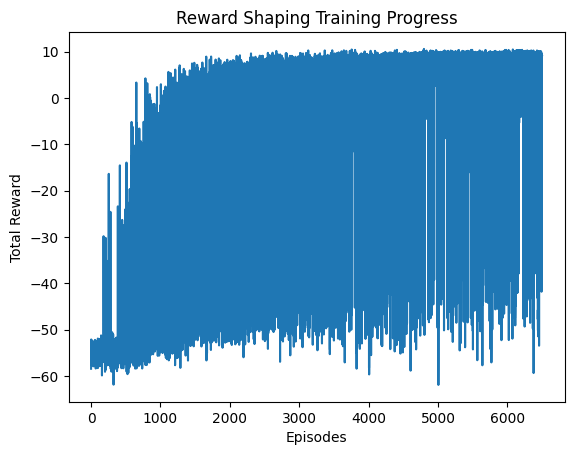

In [266]:
# Run the training.
print("🚀 Training MiniGrid-BlockedUnlockPickup-v0")
q_table, rewards = tabular_q_learning_adjust("MiniGrid-BlockedUnlockPickup-v0", episodes=6500)
plt.plot(rewards)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Reward Shaping Training Progress")
plt.show()

Now that you have trained your agent using reward shaping, let's visualize its performance in the MiniGrid-BlockedUnlockPickup Environment.
⚠️ Do not modify this cell, except for bringing over the necessary helper functions and get_state() from your training code. Any other changes will result in a score of 0 for your training code above.

Success: 16/20
Episode rewards: [0.9437, 0.9422, 0.9625, 0.9375, 0.9531, 0.0, 0.9625, 0.9484, 0.9547, 0.9469, 0.9453, 0.9469, 0.95, 0.9625, 0.9578, 0.9531, 0.0, 0.0, 0.9641, 0.0]


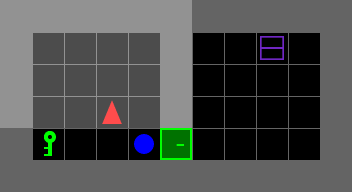

In [267]:
def run_learned_value_adjust_eps(
    env_name="MiniGrid-BlockedUnlockPickup-v0",
    q_table=None,
    n_episodes=20,
    max_steps=150,
    gif_path="./content/minigrid_q_learning_10eps.gif",
    live_display=True,
    display_every=1,
    fps=5,
    pause_between_episodes_sec=0.5,
    seed=0,
):
    """
    Runs a learned Q-table policy for n_episodes episodes, counts successes, and saves one GIF.

    Success definition:
      - success = (reward > 0) at any step (MiniGrid sparse-reward tasks typically only reward success)
    Seeding:
      - episode seed = seed + ep
      - env.reset(seed=episode_seed) and env.action_space.seed(episode_seed)
    """
    if q_table is None:
        q_table = {}

    env = gym.make(env_name, render_mode="rgb_array")
    base_env = env.unwrapped

    # TODO: Bring the helper functions and state design from your training
    # code to this evaluation function. The state representation used here
    # must match the one used during training; otherwise, the learned Q-table
    # cannot be applied correctly.
    def _iter_grid_objects():

        # Helper functions like this to read useful objects
        # from the environment grid.
        grid = base_env.grid
        for x in range(grid.width):
            for y in range(grid.height):
                obj = grid.get(x, y)
                if obj is not None:
                    yield x, y, obj

    # object types: wall, floor, ball, key, door, box
    def _find_first_obj(obj_type):

        # Helper functions to search for important objects
        # in the environment if needed for your state design or reward shaping.
        for x, y, obj in _iter_grid_objects():
            if getattr(obj, "type", None) == obj_type:
                return x, y, obj
        return None, None, None

    def _carrying_type():
        return None if base_env.carrying == None else base_env.carrying.type

    class EnvInfo:
        def __init__(self, base_env, ball_init_pos):
            self.base_env = base_env
            self.ball_init_pos = ball_init_pos

    class State:
        def __init__(self, carrying=None,
                     progress=0, next_obj_dir=(0,0), next_obj_type=None, obj_around=None):
            # basic attributes
            # self.dir = dir
            # self.pos = pos
            self.carrying = carrying

            self.progress = progress

            self.next_obj_dir = next_obj_dir
            
            self.next_obj_type = next_obj_type

            self.obj_around = obj_around

    # ---

    def done_state_tuple():
        return None, 8, None, None, None

    def fail_state_tuple():
        return None, -1, None, None, None

    def get_state(env_info: EnvInfo):

        # TODO: Design your own state representation.

        # Your state does not need to follow any fixed design, but it should
        # contain enough information for the agent to learn effectively. It is
        # recommended to include at least position-related information, the
        # agent's direction, and any additional information required by your
        # reward shaping. Think about what the agent needs to observe in order
        # to understand the behaviors you want it to learn. For example, if
        # picking up the key is rewarded, then the state should include enough
        # information for the agent to recognize that event.
        if _find_first_obj('box') == (None, None, None):
            if _carrying_type() == 'box':
                return done_state_tuple()
            # If the agent toggle the box, the box will disappear.
            return fail_state_tuple()
        base_env = env_info.base_env
        # determine state.carrying
        state = State(_carrying_type())
        
        # determine state.progress
        cur_ball_x, cur_ball_y, _ = _find_first_obj('ball')
        _, _, door_obj =  _find_first_obj('door')
        front_pos = base_env.front_pos
        front_obj = base_env.grid.get(front_pos[0], front_pos[1])
        front_obj_type = None if front_obj == None else front_obj.type

        if (cur_ball_x, cur_ball_y) == tuple(env_info.ball_init_pos):
            state.progress = 2 if state.carrying == 'ball' else 0
        elif door_obj.is_locked:
            if state.carrying == 'ball' and (front_pos[0], front_pos[1]) == tuple(env_info.ball_init_pos):
                state.progress = 1
            else:
                match state.carrying:
                    case 'ball': state.progress = 2
                    case None:   state.progress = 3
                    case 'key':  state.progress = 4
        elif not door_obj.is_open:
            state.progress = 5
        elif state.carrying != None:
            state.progress = 6
        else:
            state.progress = 7

        # determine next_object_side
        # agent dir: (0, right), (1, down), (2, left), (3, up)
        # side: (0, right), (1, back), (2, left), (3, front)
        # right: x increase, down: y increase
        state.next_obj_type = None
        match state.progress:
            case 0: state.next_obj_type = 'ball'
            case 1: state.next_obj_type = 'init_ball'
            case 3: state.next_obj_type = 'key'
            case 4 | 5: state.next_obj_type = 'door'
            case 6 | 7: state.next_obj_type = 'box'

        agent_x, agent_y = base_env.agent_pos

        if state.next_obj_type == None:
            state.next_obj_dir = -1
        else:
            next_x, next_y, _ = _find_first_obj(state.next_obj_type)
            if state.next_obj_type == 'init_ball':
                next_x, next_y = env_info.ball_init_pos

            delta_x = 0 if agent_x == next_x else (next_x - agent_x)//abs(next_x - agent_x)
            delta_y = 0 if agent_y == next_y else (next_y - agent_y)//abs(next_y - agent_y)

            # agent dir: (0, right), (1, down), (2, left), (3, up)
            # next_object_dir = ((front(1), back(-1) or none(0)), (right(1), left(-1) or none(0)))
            match base_env.agent_dir:
                case 0: state.next_obj_dir = (delta_x, delta_y)
                case 1: state.next_obj_dir = (delta_y, -delta_x)
                case 2: state.next_obj_dir = (-delta_x, -delta_y)
                case 3: state.next_obj_dir = (-delta_y, delta_x)

        dx = front_pos[0] - agent_x
        dy = front_pos[1] - agent_y
        right_pos = (agent_x - dy, agent_y + dx)
        back_pos = (agent_x - dx, agent_y - dy)
        left_pos = (agent_x + dy, agent_y - dx)

        right_obj = base_env.grid.get(right_pos[0], right_pos[1])
        back_obj = base_env.grid.get(back_pos[0], back_pos[1])
        left_obj = base_env.grid.get(left_pos[0], left_pos[1])
        right_obj_type = None if right_obj == None else right_obj.type
        back_obj_type = None if back_obj == None else back_obj.type
        left_obj_type = None if left_obj == None else left_obj.type

        state.obj_around = (right_obj_type, back_obj_type, left_obj_type, front_obj_type)

        return state.carrying, state.progress, state.next_obj_dir, state.next_obj_type, state.obj_around



    # -----------------------------
    # Rollout over episodes
    # -----------------------------
    frames = []
    success_count = 0
    ep_rewards = []

    handle = None
    fig, axp, im = None, None, None

    for ep in range(n_episodes):
        ep_seed = int(seed) + int(ep)
        env.action_space.seed(ep_seed)
        obs, info = env.reset(seed=ep_seed)

        init_ball_x, init_ball_y, _ = _find_first_obj('ball')
        ball_init_pos = np.array([init_ball_x, init_ball_y])
        env_info = EnvInfo(base_env, ball_init_pos)

        state_tuple = get_state(env_info)
        state = State(*state_tuple)
        total_reward = 0.0
        success = False

        frame = env.render()
        frames.append(frame.copy())

        if live_display and (handle is None):
            fig, axp = plt.subplots()
            im = axp.imshow(frame)
            axp.axis("off")
            axp.set_title(f"Ep {ep+1}/{n_episodes} | Step 0")
            handle = display(fig, display_id=True)
            plt.close(fig)

        for t in range(max_steps):
            action = env.action_space.sample() if state_tuple not in q_table else int(np.argmax(q_table[state_tuple]))

            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            r = float(reward)
            total_reward += r
            if r > 0.0:
                success = True

            state_tuple = get_state(env_info)
            state = State(*state_tuple)

            frame = env.render()
            frames.append(frame.copy())

            if live_display and (t % display_every == 0):
                im.set_data(frame)
                axp.set_title(
                    f"Ep {ep+1}/{n_episodes} | Step {t+1} | action={action} "
                    f"| ep_reward={total_reward:.2f} | success={int(success)}"
                )
                handle.update(fig)

            if done:
                break

        success_count += int(success)
        ep_rewards.append(total_reward)

        if pause_between_episodes_sec and pause_between_episodes_sec > 0:
            k = int(round(pause_between_episodes_sec * fps))
            if k > 0:
                last_frame = frames[-1]
                for _ in range(k):
                    frames.append(last_frame.copy())

    env.close()

    imageio.mimsave(gif_path, frames, fps=fps)

    print(f"Success: {success_count}/{n_episodes}")
    print("Episode rewards:", [round(r, 4) for r in ep_rewards])

    return Image(filename=gif_path)

run_learned_value_adjust_eps("MiniGrid-BlockedUnlockPickup-v0", q_table, live_display=False, display_every=1, seed=0)



# **Question 3: Implementing Tabular Learning with PyTorch**  

So far, we have implemented **Tabular Q-learning** using **NumPy** to store and update the Q-table.  
However, in real-world **reinforcement learning**, deep learning frameworks like **PyTorch** are often used to handle **large state spaces** and optimize learning.  

In this question, we will still use **tabular learning**, but instead of **NumPy**, we will implement **Q-learning** and **Policy Learning** using **PyTorch**.  


✅ **Q-Learning Implementation (10 Points)**  
- Correctly implements **Q-learning using PyTorch tensors** instead of NumPy.  
- Successfully **trains the agent** and **demonstrates an animation of reaching the goal**.  

✅ **Policy Learning Implementation (10 Points)**  
- Correctly implements **policy-based learning using PyTorch**, including a **softmax policy**.  
- Successfully **trains the agent** and **demonstrates an animation of reaching the goal**.  

🚀 **Full Score (20 Points)**: If both Q-learning and Policy Learning are implemented correctly and the agent **successfully reaches the goal**, you have **earned all 20 points! 🎉**  

In [11]:
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim

def get_agent_state(env):
    # TODO: Represent the state using the agent's position and direction.
    agent_pos = tuple(env.unwrapped.agent_pos)
    direction = env.unwrapped.agent_dir
    x,y = agent_pos
    return ( x , y , direction)



class PyTorchQTable:
    def __init__(self, state_size, action_size, lr=0.1):
        """
          PyTorch Q-table Implementation.
          - Stores Q-values as a PyTorch tensor.
          - Uses gradient-based updates instead of direct assignment.
          - Optimizes learning using Mean Squared Error (MSE).
        """
        self.state_size = state_size
        self.action_size = action_size

        # TODO: Initialize the Q-table as a PyTorch tensor.
        # the shape is (width, height, direction, action_size)
        self.q_table = torch.zeros((*state_size, action_size), requires_grad=True)

        # TODO: Use Stochastic Gradient Descent (SGD) or Adam for optimization.
        self.optimizer = optim.SGD([self.q_table], lr=lr)

        # TODO: Use Mean Squared Error (MSE) loss for training.
        self.criterion = nn.MSELoss()


    def update(self, state, action, target):
        """
        Update the Q-value using PyTorch optimization.
        """
        self.optimizer.zero_grad()

        # TODO: Retrieve the current Q-value.
        current_q = self.q_table[state[0], state[1], state[2], action]

        # TODO: Compute the MSE loss.
        loss = self.criterion(current_q, torch.tensor(target, dtype=torch.float32))

        # TODO: Perform backpropagation.
        loss.backward()

        # TODO: Perform gradient descent.
        self.optimizer.step()

    def get_action(self, state, epsilon):
        # TODO: Implements ε-greedy action selection.
        if np.random.random() < epsilon:
            return np.random.randint(0, self.action_size)
        else:
            with torch.no_grad():
                q_vals = self.q_table[state[0], state[1], state[2]]
                return torch.argmax(q_vals).item()


def train_pytorch_q_learning(
    env_name="MiniGrid-Empty-8x8-v0",
    episodes=2000,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.1,
    decay_rate=0.999,
    seed=0
):

    env = gym.make(env_name)
    base_env = env.unwrapped
    state_size = (base_env.width, base_env.height, 4)  # (x, y, direction)
    action_size = env.action_space.n

    q_table = PyTorchQTable(state_size, action_size, lr=alpha)
    epsilon = epsilon_start

    for episode in range(episodes):
        obs, _ = env.reset(seed=seed + episode)
        state = get_agent_state(env)

        terminated = False
        truncated = False
        total_reward = 0.0

        while not (terminated or truncated):
            action = q_table.get_action(state, epsilon)

            obs, reward, terminated, truncated, _ = env.step(action)
            next_state = get_agent_state(env)

            # TODO: Implement Q-learning using PyTorch Q-table.
            with torch.no_grad():
                next_q_values = q_table.q_table[next_state[0], next_state[1], next_state[2]]
                max_next_q = torch.max(next_q_values)
                # 如果是終止狀態，就沒有未來報酬
                target = reward + (0 if terminated else gamma * max_next_q.item())

            q_table.update(state, action, target)

            state = next_state
            total_reward += float(reward)

        epsilon = max(epsilon_end, epsilon * decay_rate)

        if (episode + 1) % 100 == 0:
            print(f"Episode {episode + 1}/{episodes}, Total Reward: {total_reward}, Epsilon: {epsilon:.3f}")

    env.close()
    return q_table





Train the agent in MiniGrid-Empty-8x8 with PyTorch Q-learning.

⚠️ **Any changes** will result in a score of **0** for your training code above.

In [ ]:
print("🚀 Training PyTorch Q-learning on MiniGrid-Empty-8x8")
q_table = train_pytorch_q_learning("MiniGrid-Empty-8x8-v0", episodes=2000)

In [ ]:
import gymnasium as gym
import imageio
from IPython.display import Image

def run_pytorch_q_learning(env_name="MiniGrid-Empty-8x8-v0", q_table=None, max_steps=100, gif_path="./content/minigrid_q_learning.gif"):

    env = gym.make(env_name, render_mode="rgb_array")
    obs, _ = env.reset()
    state = get_agent_state(env)

    frames = []
    total_reward = 0.0

    frames.append(env.render())

    for _ in range(max_steps):
        action = q_table.get_action(state, epsilon=0.0)

        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += float(reward)
        state = get_agent_state(env)


        frames.append(env.render())

        if terminated or truncated:
            break

    env.close()

#Do not modify the code below—any changes will result in a score of 0 for your training code above.
    imageio.mimsave(gif_path, frames, fps=5)
    print(f"Total Reward: {total_reward}")

    return Image(filename=gif_path)

run_pytorch_q_learning("MiniGrid-Empty-8x8-v0", q_table)

Instead of directly updating **Q-values**, we will now train an explicit **policy** using **Softmax Policy Gradients**.  

### **📌 What is Softmax Policy Gradient?**  
In **value-based reinforcement learning** (e.g., Q-learning), an agent **learns a Q-table** that estimates the value of each action in a given state. However, instead of storing and updating Q-values, **policy-based methods** directly learn a **policy** that maps states to actions.  

The **Softmax Policy Gradient** approach uses a **probabilistic policy representation**, where action selection is based on a **Softmax function** applied to policy scores. This enables the agent to explore actions **proportionally to their estimated effectiveness**, rather than always selecting the highest-value action.  

### **🛠 How Does It Work?**  
1. **The policy is represented by a probability distribution** over actions for each state.  
2. **The agent selects an action using Softmax probabilities**, rather than choosing greedily based on a Q-table.  
3. **The policy is updated using gradient ascent**, optimizing a loss function (e.g., Cross-Entropy Loss).  
4. **The agent improves its action selection strategy over time** by reinforcing actions that lead to higher rewards.  

### **🎯 Why Use Softmax Policy Gradients?**  
- ✅ **Handles large state spaces** more effectively than tabular Q-learning.  
- ✅ **Encourages exploration** by selecting actions probabilistically instead of always taking the best-known action.  
- ✅ **More suitable for stochastic environments**, where actions should not always be deterministic.  
- ✅ **Lays the foundation for deep policy-based RL**, such as REINFORCE and Actor-Critic methods.  

In this section, we will implement **policy learning** using **PyTorch** and train the agent using the **Softmax Policy Gradient method**.


In [15]:
import torch.nn.functional as F
def get_agent_state(env):
    # TODO: Represent the state using the agent's position and direction.
    agent_pos = tuple(env.unwrapped.agent_pos)
    direction = env.unwrapped.agent_dir
    x,y = agent_pos
    return ( x , y , direction)

class PyTorchPolicy:
    def __init__(self, state_size, action_size, lr=0.1):
        '''
          Implements a Softmax Policy using PyTorch.
          - Uses **log probabilities** for policy updates.
          - Optimized using **REINFORCE** with policy gradients.
        '''
        self.state_size = state_size
        self.action_size = action_size

        # TODO: Initialize the policy tensor (logits)
        self.logits_table = torch.zeros((*state_size, action_size), requires_grad=True)

        # TODO: Use **Adam optimizer** for policy optimization.
        self.optimizer = optim.Adam([self.logits_table], lr=lr)

    def get_action(self, state):

        # TODO: Sample an action based on **Softmax probabilities**.
        logits = self.logits_table[state[0], state[1], state[2]]
        pi = F.softmax(logits, dim=-1)
        m = torch.distributions.Categorical(pi)
        action = m.sample()

        return action  # Return log probability
        # why return log probability???

    def update(self, state, action, reward):
        self.optimizer.zero_grad()

        action_tensor = torch.tensor(action, dtype=torch.long)

        # TODO: Fetch the policy logits for the given state from the logits table.
        logits = self.logits_table[state[0], state[1], state[2]]

        # TODO: Compute log-probabilities with log_softmax, then select log-prob of the taken action.
        log_probs = F.log_softmax(logits, dim=-1)
        selected_log_prob = log_probs[action]

        # TODO: Compute the REINFORCE loss: negative reward times log-prob of the taken action.
        loss = -reward * selected_log_prob

        # TODO: Backpropagate gradients through the logits table.
        loss.backward()

        # TODO: Take an optimizer step to update parameters (gradient descent).
        self.optimizer.step()



def train_pytorch_policy_learning(env_name="MiniGrid-Empty-8x8-v0", episodes=5000, alpha=0.05, gamma=0.99):
    '''
      Train Policy Learning using **Softmax Policy Gradient**.
      - Uses **log probability gradient**.
      - Optimizes policy using **Adam**.
    '''
    env = gym.make(env_name)
    base_env = env.unwrapped
    state_size = (base_env.width, base_env.height, 4)
    action_size = env.action_space.n

    policy_model = PyTorchPolicy(state_size, action_size, lr=alpha)


    for episode in range(episodes):
        obs, _ = env.reset()

        state = get_agent_state(env)

        done = False
        total_reward = 0
        trajectory = []


        while not done:
            # TODO: Sample an action from the current stochastic policy (e.g., softmax over logits).
            action = policy_model.get_action(state)

            # TODO: Step the environment with the sampled action and obtain (obs, reward, termination flags).
            next_obs, reward, terminated, truncated, _ = env.step(action)

            done = done or truncated
            trajectory.append((state, action, reward))
            state = get_agent_state(env)
            total_reward += reward

        # Compute discounted returns G_t
        G = 0
        stored_G = []

        # TODO: Traverse the trajectory backward to compute discounted return:
        for _, _, r in reversed(trajectory):
            G = r + gamma * G
            stored_G.append(G)

        stored_G.reverse()

        # TODO: Iterate forward again; for each timestep t, retrieve its return G_t
        #         and update the policy using REINFORCE: loss = -G_t * log π(a_t | s_t)
        for i in range(len(trajectory)):
            state, action, _ = trajectory[i]
            G = stored_G[i]
            policy_model.update(state, action, G)

        # Print progress every 100 episodes.
        if (episode + 1) % 100 == 0:
            print(f"🚀 Episode {episode + 1}/{episodes}, Total Reward: {total_reward}")

    env.close()
    return policy_model


Train the agent in MiniGrid-Empty-8x8 with PyTorch policy learning.

⚠️ **You can only adjust the episodes in this cell**—any others changes will result in a score of **0** for your training code above.

In [ ]:
print("🚀 Training PyTorch Policy Learning on MiniGrid-Empty-8x8")
policy_model = train_pytorch_policy_learning("MiniGrid-Empty-8x8-v0", episodes=2000)

Now that you have trained your agent using **PyTorch policy learning**, let's visualize its performance in the **MiniGrid environment**.  

This function runs a **test episode** using the learned **policy table (π-table)** and records the agent's movement as a **GIF**.

⚠️ Do not modify this cell—any changes will result in a score of 0 for your training code above.


In [ ]:
def run_pytorch_policy_learning(env_name, policy_model, max_steps=100, gif_path="./content/minigrid_policy_learning.gif"):

    env = gym.make(env_name, render_mode="rgb_array")
    obs, _ = env.reset()
    state = get_agent_state(env)

    frames = []
    total_reward = 0.0

    frames.append(env.render())

    for _ in range(max_steps):
        action = policy_model.get_action(state)
        obs, reward, terminated, truncated, _ = env.step(action)

        total_reward += float(reward)
        state = get_agent_state(env)

        frames.append(env.render())

        if terminated or truncated:
            break

    env.close()

    imageio.mimsave(gif_path, frames, fps=5)
    print(f"Total Reward: {total_reward}")
    return Image(filename=gif_path)

print("🚀 Running PyTorch Policy Learning agent")
run_pytorch_policy_learning("MiniGrid-Empty-8x8-v0", policy_model)